In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

print(" Bibliothèques importées")

 Bibliothèques importées


In [3]:
df = pd.read_csv('../data/processed/dataset_clean.csv')

# Prendre seulement les colonnes numériques (ignorer les labels)
features = ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite']
X = df[features].dropna()

print(f"Shape : {X.shape}")
print("Labels ignorés — mode non supervisé")

Shape : (7174, 5)
Labels ignorés — mode non supervisé


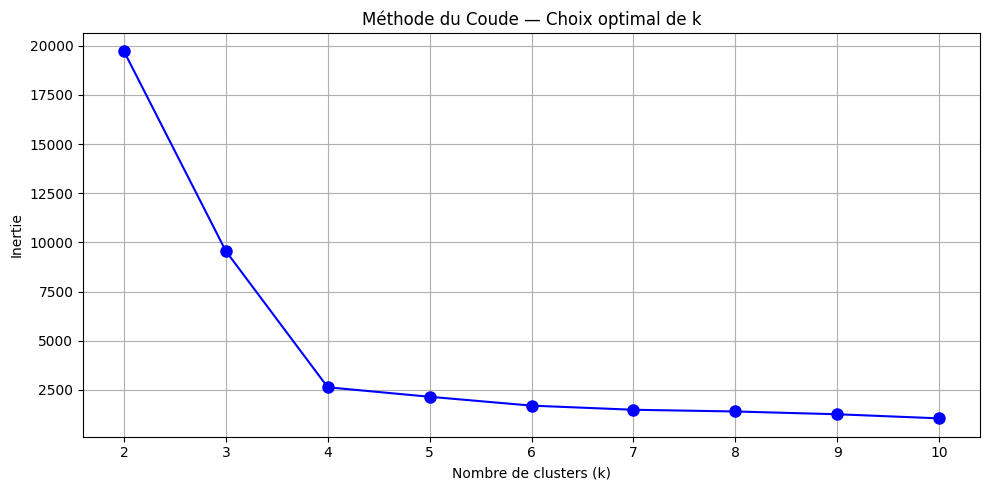

In [4]:
inerties = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inerties.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K, inerties, 'bo-', markersize=8)
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie')
plt.title('Méthode du Coude — Choix optimal de k')
plt.xticks(K)
plt.grid(True)
plt.tight_layout()
plt.show()

k=2 → Silhouette: 0.5851
k=3 → Silhouette: 0.7535
k=4 → Silhouette: 0.7854
k=5 → Silhouette: 0.5968
k=6 → Silhouette: 0.5074
k=7 → Silhouette: 0.5084
k=8 → Silhouette: 0.4926
k=9 → Silhouette: 0.4051
k=10 → Silhouette: 0.4128


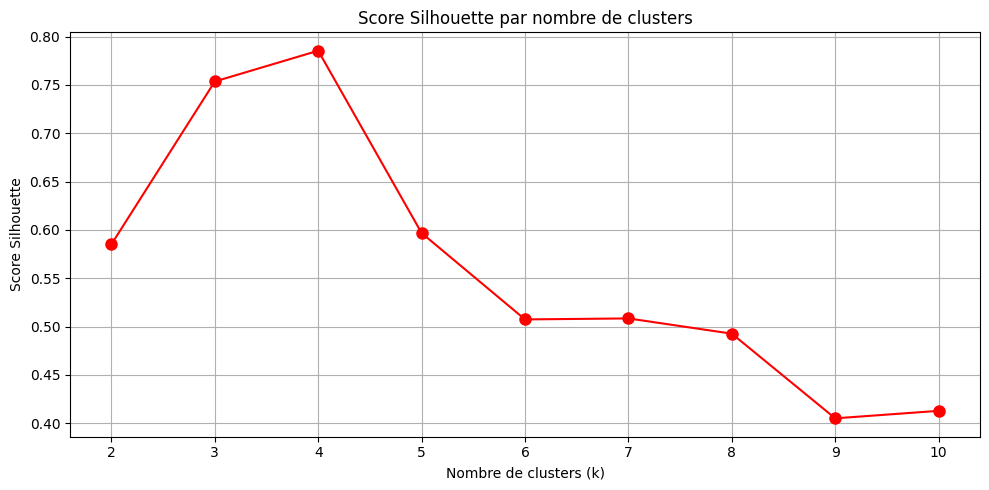

In [5]:
silhouettes = []

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouettes.append(score)
    print(f"k={k} → Silhouette: {score:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(K, silhouettes, 'ro-', markersize=8)
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Score Silhouette')
plt.title('Score Silhouette par nombre de clusters')
plt.xticks(K)
plt.grid(True)
plt.tight_layout()
plt.show()

In [6]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_clusters = kmeans_final.fit_predict(X)

print(f"✅ KMeans appliqué avec k=4")
print(f"Distribution des clusters :")
unique, counts = np.unique(labels_clusters, return_counts=True)
for u, c in zip(unique, counts):
    print(f"   Cluster {u} : {c} points")

✅ KMeans appliqué avec k=4
Distribution des clusters :
   Cluster 0 : 3644 points
   Cluster 1 : 1947 points
   Cluster 2 : 1506 points
   Cluster 3 : 77 points


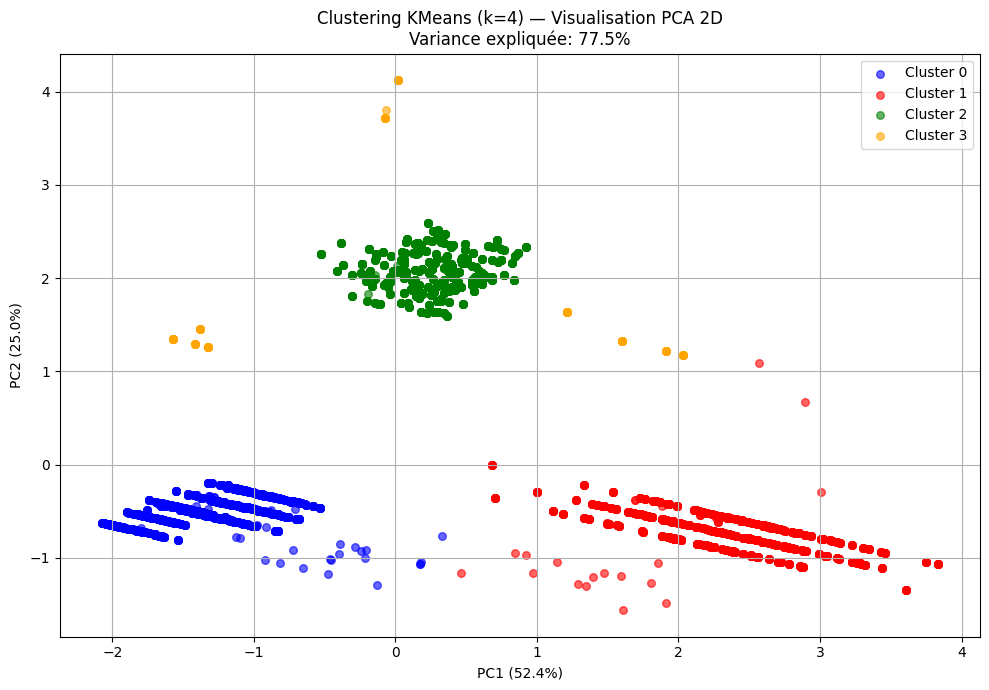

In [7]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 7))
colors = ['blue', 'red', 'green', 'orange']
for i in range(4):
    mask = labels_clusters == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[i], label=f'Cluster {i}',
                alpha=0.6, s=30)

plt.title(f'Clustering KMeans (k=4) — Visualisation PCA 2D\nVariance expliquée: {sum(pca.explained_variance_ratio_)*100:.1f}%')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()